In [1]:
import numpy as np

In [5]:
def skew(k):
    kx, ky, kz = k
    return np.array([
        [0,  -kz,  ky],
        [kz,  0,  -kx],
        [-ky, kx,  0]
    ])

def dir_axang(k, theta):

    k = np.asarray(k).reshape(-1)

    if k.size != 3:
        raise ValueError("k debe ser un vector de R3")

    k = k / np.linalg.norm(k)

    I = np.eye(3)

    R = (np.cos(theta) * I +
         (1 - np.cos(theta)) * np.outer(k, k) +
         np.sin(theta) * skew(k))


    return R

In [6]:
# Versión más estable que usar descomposición en autovectores
def inv_axang(R):    
    theta = np.arccos((np.trace(R) - 1) / 2)

    if np.isclose(theta, 0):
        # rotación nula
        k = np.array([1,0,0])
    else:
        k = np.array([
            R[2,1] - R[1,2],
            R[0,2] - R[2,0],
            R[1,0] - R[0,1]
        ]) / (2*np.sin(theta))

    return k, theta

In [ ]:
k = [0, 0, 1]
theta = np.pi/4

R = dir_axang(k, theta)
print(R)

k_rec, theta_rec = inv_axang(R)
print("Diferencia en eje recuperado: ",k_rec-k)
print("Diferencia en ángulo recuperado: ",theta_rec-theta)

# Se observa que la descomposición en autovalores y autovectores nos da el vector de rotación.
# Los autovalores de una matriz ortonormal son (1,e^(i theta),e^-(i theta) ) 
V,l = np.linalg.eig(R)
print(V)
print(l)


[[ 0.70710678 -0.70710678  0.        ]
 [ 0.70710678  0.70710678  0.        ]
 [ 0.          0.          1.        ]]
Diferencia en eje recuperado:  [ 0.00000000e+00  0.00000000e+00 -1.11022302e-16]
Diferencia en ángulo recuperado:  1.1102230246251565e-16
[0.70710678+0.70710678j 0.70710678-0.70710678j 1.        +0.j        ]
[[0.70710678+0.j         0.70710678-0.j         0.        +0.j        ]
 [0.        -0.70710678j 0.        +0.70710678j 0.        +0.j        ]
 [0.        +0.j         0.        -0.j         1.        +0.j        ]]


## Cuaterniones

In [17]:
def dir_quat(q):
    q = np.asarray(q, dtype=float)
    q = q / np.linalg.norm(q)

    g, qx, qy, qz = q

    theta = 2*np.arccos(g)

    s = np.sqrt(1 - g*g)

    if np.isclose(s, 0):
        # rotación nula: eje arbitrario
        k = np.array([1.0, 0.0, 0.0])
    else:
        k = np.array([qx, qy, qz]) / s

    R = dir_axang(k, theta)

    return R

Recordar

$$R(\vec{Q})=\begin{bmatrix} 
2q_x q_x +2g^2-1 & 2q_x q_y -2g q_z & 2q_x q_z +2g q_y \\
2q_x q_y +2g q_z & 2q_y q_y +2g^2-1 & 2q_y q_z -2g q_x \\ 
2q_x q_z -2g q_y & 2q_z q_y +2g q_x & 2q_z q_z +2g^2 -1 
\end{bmatrix}
$$

In [18]:
def inv_quat(R):

    R = np.asarray(R)
    tr = np.trace(R)

    if tr > 0:
        g = 0.5 * np.sqrt(tr + 1)

        qx = (R[2,1] - R[1,2]) / (4*g)
        qy = (R[0,2] - R[2,0]) / (4*g)
        qz = (R[1,0] - R[0,1]) / (4*g)

    else:
        # elegir la diagonal dominante
        i = np.argmax([R[0,0], R[1,1], R[2,2]])

        if i == 0:
            qx = 0.5 * np.sqrt(1 + R[0,0] - R[1,1] - R[2,2])
            g  = (R[2,1] - R[1,2]) / (4*qx)
            qy = (R[0,1] + R[1,0]) / (4*qx)
            qz = (R[0,2] + R[2,0]) / (4*qx)

        elif i == 1:
            qy = 0.5 * np.sqrt(1 - R[0,0] + R[1,1] - R[2,2])
            g  = (R[0,2] - R[2,0]) / (4*qy)
            qx = (R[0,1] + R[1,0]) / (4*qy)
            qz = (R[1,2] + R[2,1]) / (4*qy)

        else:
            qz = 0.5 * np.sqrt(1 - R[0,0] - R[1,1] + R[2,2])
            g  = (R[1,0] - R[0,1]) / (4*qz)
            qx = (R[0,2] + R[2,0]) / (4*qz)
            qy = (R[1,2] + R[2,1]) / (4*qz)

    q = np.array([g, qx, qy, qz])

    return q / np.linalg.norm(q)

## Ejercicio

- Encontrar la matriz de rotación que expresa la orientación de la terna 2 respecto de la 0
- Encontrar el cuaternión Q que expresa la misma rotación

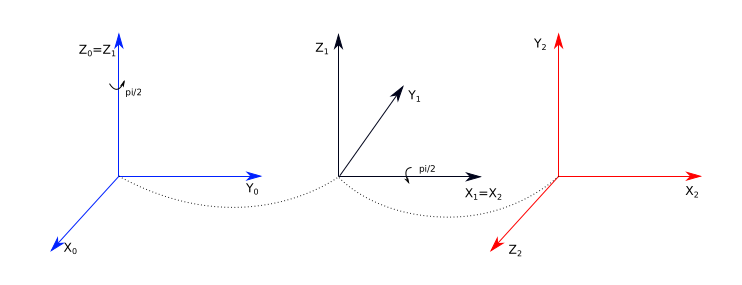


In [15]:
# Puedo expresar la orientación como composición de rotaciones
R = dir_axang([0,0,1],np.pi/2) @ dir_axang([1,0,0],np.pi/2)
print("Matriz de rotación R=\n",np.round(R, 6))

print(np.linalg.det(R))

Matriz de rotación R=
 [[ 0. -0.  1.]
 [ 1.  0. -0.]
 [ 0.  1.  0.]]
1.0


In [19]:
# Obtengo el cuaternión

Q = inv_quat(R)
print(Q)

[0.5 0.5 0.5 0.5]


In [22]:
# Obtengo el eje de rotación

k,theta = inv_axang(R)
print("Eje de rotación k=",k)
print("Ángulo de rotación theta=",theta)

Eje de rotación k= [0.57735027 0.57735027 0.57735027]
Ángulo de rotación theta= 2.0943951023931953


In [45]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# dibujar una terna
def draw_frame(ax, R):
    origin = np.zeros(3)
    colors = ['r','g','b']
    for i in range(3):
        v = R[:,i]
        ax.quiver(*origin, *v, color=colors[i], linewidth=2)

# dibujar el eje
def draw_axis(ax, k, L=1.5):
    k = k / np.linalg.norm(k)
    p1 = -L * k
    p2 =  L * k
    ax.plot(
        [p1[0], p2[0]],
        [p1[1], p2[1]],
        [p1[2], p2[2]],
        color='k',
        linewidth=1
    )

steps = 50

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

#ax.view_init(elev=40, azim=30)
ax.set_axis_off()

def update(frame):

    ax.cla()

    ax.set_xlim([-1,1])
    ax.set_ylim([-1,1])
    ax.set_zlim([-1,1])

    ax.set_axis_off()

    # frame base
    draw_frame(ax, np.eye(3))

    # dibujar eje
    draw_axis(ax, k)

    # rotación progresiva
    angle = theta * frame/steps

    R = dir_axang(k, angle)

    draw_frame(ax, R)

ani = FuncAnimation(fig, update, frames=steps, interval=50)
plt.close(fig)
HTML(ani.to_jshtml())